PROJECT 6: SIMPLE NEURAL NETWORK FORWARD PROPAGATION

Objective
: The objective of this project is to understand how a simple neural network performs forward propagation using the Iris classification dataset. The input features are passed through a hidden layer, an activation function is applied, and the network produces predictions for different Iris flower species.

Task 1: Load and Prepare the Iris Dataset
Explanation
The Iris dataset is a popular dataset used for classification. It contains information about three types of Iris flowers:
- Setosa
- Versicolor
- Virginica
Each flower has four input features:
1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width
The dataset contains 150 samples. We divide the data into training and testing sets and standardize the input features.

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Class Names:", iris.target_names)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize the input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Dataset Shape: (150, 4)
Class Names: ['setosa' 'versicolor' 'virginica']
Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


Task 2: Build a Simple Neural Network
Explanation

A simple neural network consists of an input layer, hidden layer, and output layer.
In this project:
- Input layer has 4 neurons, representing the four Iris features.
- Hidden layer has 5 neurons.
- Output layer has 3 neurons, representing the three Iris flower classes.
Weights and biases are used to perform the mathematical calculations between the layers.

In [4]:
# Set random seed
np.random.seed(42)

# Define the number of neurons
input_size = 4
hidden_size = 5
output_size = 3

# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# ReLU activation function
def relu(x):
    return np.maximum(0, x)

# Softmax activation function
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Forward propagation
Z1 = np.dot(X_test, W1) + b1
A1 = relu(Z1)

Z2 = np.dot(A1, W2) + b2
A2 = softmax(Z2)

print("Forward Propagation Completed!")
print("Output Probabilities:")
print(A2[:5])

Forward Propagation Completed!
Output Probabilities:
[[3.47929208e-01 3.24023165e-01 3.28047626e-01]
 [3.94219098e-07 4.65811966e-08 9.99999559e-01]
 [6.62731129e-02 7.73057403e-01 1.60669484e-01]
 [3.07386790e-01 3.65444960e-01 3.27168249e-01]
 [1.64484836e-01 1.96208415e-01 6.39306749e-01]]


Task 3: Apply an Activation Function and Display the Predicted Output

Description: Use the Softmax output probabilities to identify the predicted Iris flower species. The argmax() function selects the class with the highest probability.

In [5]:
# Get predicted classes
predicted_classes = np.argmax(A2, axis=1)

# Convert class numbers into flower names
predicted_names = iris.target_names[predicted_classes]
actual_names = iris.target_names[y_test]

# Display predictions
print("Predicted Iris Flower Species:\n")

for i in range(10):
    print(
        "Predicted:", predicted_names[i],
        "| Actual:", actual_names[i]
    )

Predicted Iris Flower Species:

Predicted: setosa | Actual: versicolor
Predicted: virginica | Actual: setosa
Predicted: versicolor | Actual: virginica
Predicted: versicolor | Actual: versicolor
Predicted: virginica | Actual: versicolor
Predicted: virginica | Actual: setosa
Predicted: setosa | Actual: versicolor
Predicted: versicolor | Actual: virginica
Predicted: virginica | Actual: versicolor
Predicted: virginica | Actual: versicolor


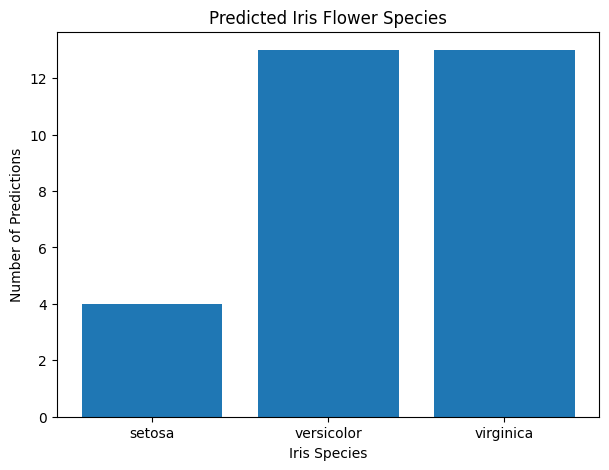

In [6]:
import matplotlib.pyplot as plt

# Count predicted classes
unique_classes, counts = np.unique(predicted_classes, return_counts=True)

# Get flower names
flower_names = iris.target_names[unique_classes]

# Create bar graph
plt.figure(figsize=(7, 5))
plt.bar(flower_names, counts)

plt.xlabel("Iris Species")
plt.ylabel("Number of Predictions")
plt.title("Predicted Iris Flower Species")
plt.show()



The program displays the predicted and actual flower species for the first ten test samples.

Result

The Iris dataset was successfully loaded and prepared. A simple neural network was created using four input neurons, five hidden neurons, and three output neurons. Forward propagation was performed using ReLU and Softmax activation functions to generate classification predictions.

Conclusion

This project demonstrates the working of forward propagation in a neural network. It explains how input features pass through different layers, how activation functions process the values, and how the network generates predictions for Iris flower species.